# 🎯 *Aprendizaje Automático en Negocios - Métricas, A/B Testing y Bootstrap* 🎯

---


In [63]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
from scipy.stats import ttest_ind



In [64]:
sns.set(style="whitegrid", palette="pastel")


## 🧩 *Métricas generales de negocio*

**📈 Conceptos clave:**
* *Ingresos:* lo que entra 💰
* *Coste de bienes vendidos (COGS):* lo que cuesta producir 🏭
* *Beneficio bruto:* `ingresos - COGS`
* *Margen bruto:* `(beneficio bruto / ingresos)`
* *Gastos operativos:* renta, sueldos, marketing...
* *Beneficio operativo:* `beneficio bruto - gastos operativos`
* *Beneficio neto:* lo que realmente se gana (después de impuestos)
* *ROI:* `beneficio neto / inversión`
* *Conversión:* usuarios que completan una acción (ej. compra)
* *Embudos:* visualizan pasos como visitante → cliente

**💡 Intuición:**
Estas métricas son el puente entre el mundo de los datos y el negocio real. ¡No basta con tener un modelo preciso! Lo que importa es si mejora ingresos, conversión o rentabilidad.

### 🧪 Análisis de resultados de campañas de marketing

Eres parte del equipo de análisis de una empresa digital que ha implementado varias campañas de marketing para atraer usuarios y generar conversiones en su plataforma. Ahora cuentas con tres conjuntos de datos clave que te permitirán realizar un análisis integral del desempeño de las campañas:



1. **Interacciones y transacciones `orders`:**  
   - Cada registro representa una interacción de usuario que resultó en una transacción.
   - Columnas: `uuid_interaction` (ID de interacción), `transaction_ts` (fecha/hora), `items` (artículos comprados), `amount` (monto total).

2. **Costos de campañas `campaign_detaials` :**  
   - Información de costos fijos y variables para cada campaña.
   - Columnas: `id_campaña`, `costo_base_campaña`, `costo_por_dia_activo_campaña`, `costo_por_interaccion_campaña`.

3. **Visitas y conversiones de usuarios `visits`:**  
   - Cada registro representa una visita de usuario a la plataforma, asociada a una campaña.
   - Columnas: `uuid_user` (ID de usuario), `ts_visits` (fecha/hora), `campaign` (ID de campaña), `uuid_interaction` (ID de interacción), `convertion` (1 si hubo conversión, 0 si no).



#### Sugerencias de análisis de interés

- **Ingresos y artículos vendidos por campaña:** Suma el monto total y la cantidad de artículos vendidos asociados a cada campaña.
- **Rentabilidad de campañas:** Relaciona los ingresos y conversiones generados con los costos totales (base, por día y por interacción) para identificar campañas más rentables.
- **Eficiencia de inversión:** Calcula métricas como el costo por conversión, el ingreso por visita y el retorno de inversión (ROI) para cada campaña.

Con estos análisis podrás obtener una visión completa del desempeño de las campañas, identificar oportunidades de mejora y tomar decisiones informadas para optimizar futuras estrategias

In [65]:
#carga de datos

visits =pd.read_csv("https://raw.githubusercontent.com/zyntonyson/bootcamp_ds_da/refs/heads/main/datasets/visits.csv")
orders =pd.read_csv("https://raw.githubusercontent.com/zyntonyson/bootcamp_ds_da/refs/heads/main/datasets/orders.csv")
campaigns_details =pd.read_csv("https://raw.githubusercontent.com/zyntonyson/bootcamp_ds_da/refs/heads/main/datasets/campaigns_details.csv")


**Ingresos  por campaña:**

In [66]:
# Revenue por campaña y clientes
revenue_campaign=(
    orders
        .merge(visits[['uuid_interaction','campaign','uuid_user']].drop_duplicates(),on='uuid_interaction')
        .groupby(['campaign'],as_index=False)
        .agg(
            revenue = ('amount','sum'),
            clientes = ('uuid_user','nunique')
        )
        #.style.format({'revenue':'$ {:,.2f}'})
)

revenue_campaign

,campaign,revenue,clientes
0,1,2842345,1674
1,2,8186761,4476
2,3,39700716,18400
3,4,55476726,23722
4,5,3010738,1694
5,6,39938766,18415


**Interacciones por campaña:**

In [67]:

campaign_summary=(
    visits
        .assign(
            ts_visits = lambda df: pd.to_datetime(df.ts_visits) ,
            date_visits = lambda df: df.ts_visits.dt.date

        )
        .groupby(['campaign'],as_index=False)
        .agg(
            visitas = ('uuid_interaction','nunique'),
            rate_convertion = ('convertion','mean'),
            init_campaign = ('ts_visits','min'),
            end_campaign = ('ts_visits','max'),
        )
        .assign(
        days_elapsed_campaign= lambda df: (df.end_campaign - df.init_campaign).dt.days ,
        rate_convertion = lambda df: df.rate_convertion.round(3),
        convertions = lambda df: (df.rate_convertion*df.visitas).round(0)

    )
    .drop(columns=['init_campaign','end_campaign'])
)

campaign_summary

,campaign,visitas,rate_convertion,days_elapsed_campaign,convertions
0,1,26251,0.064,39,1680.0
1,2,43396,0.108,39,4687.0
2,3,95459,0.240,39,22910.0
3,4,113425,0.282,39,31986.0
4,5,26167,0.066,39,1727.0
5,6,95565,0.240,39,22936.0


**Rentabilidad por campaña**

In [68]:
def get_romi(row):
    # Costos individuales
    base = row['costo_base_campaña']
    costo_dias = row['costo_por_dia_activo_campaña'] * row['days_elapsed_campaign']
    costo_interacciones = row['costo_por_interaccion_campaña'] * row['visitas']
    
    # Costo total
    costo_total = base + costo_dias + costo_interacciones
    
    # Ingreso
    revenue = row['revenue']
    
    # ROMI
    if costo_total == 0:
        return float('nan')  # Venta organica
    return (revenue - costo_total) / costo_total

In [69]:
#Costos-rentabilidad

campaign_results=(campaign_summary
    .merge(revenue_campaign)
    .merge(campaigns_details, left_on='campaign',right_on='id_campaña')
    .assign(
        ROMI = lambda df: df.apply(get_romi,axis=1)
    )
)

In [70]:
campaign_results[['campaign', 'costo_base_campaña',  'days_elapsed_campaign', 'costo_por_dia_activo_campaña', 'costo_por_interaccion_campaña',  'visitas', 'revenue','ROMI']]

,campaign,costo_base_campaña,days_elapsed_campaign,costo_por_dia_activo_campaña,costo_por_interaccion_campaña,visitas,revenue,ROMI
0,1,90044.982730,39,49.805662,73.834513,26251,2842345,0.400020
1,2,90069.241497,39,235.542067,70.639774,43396,8186761,1.586868
2,3,89990.457114,39,8.882014,77.362081,95459,39700716,4.310959
3,4,89848.992308,39,68.656040,133.136031,113425,55476726,2.651351
4,5,90239.926804,39,170.658846,183.339387,26167,3010738,-0.384853
5,6,89813.401150,39,121.915022,102.321629,95565,39938766,3.045278


**Embudo de conversión**

In [72]:
def draw_funnel(data_funnel: dict):
    """
    Dibuja un embudo de conversión como un triángulo invertido con etiquetas y tasas de conversión.

    Args:
        data (dict): etapas del embudo (de mayor a menor) con sus valores.
    """
    stages = list(data_funnel.keys())
    values = list(data_funnel.values())
    n = len(stages)

    fig, ax = plt.subplots(figsize=(7, 8))

    # Triángulo invertido
    bottom = [0.5, 0.0]
    top_left = [0.0, 1.0]
    top_right = [1.0, 1.0]

    triangle = patches.Polygon([top_left, top_right, bottom], closed=True,
                                edgecolor='black', facecolor='white', linewidth=2)
    ax.add_patch(triangle)

    # Líneas horizontales divisorias
    for i in range(1, n):
        y = i / n
        x1 = 0.5 - 0.5 * (1 - y)
        x2 = 0.5 + 0.5 * (1 - y)
        ax.plot([x1, x2], [1 - y, 1 - y], color='black')

    # Etiquetas de etapas y tasas de conversión
    for i in range(n):
        y_top = 1 - (i / n)
        y_bottom = 1 - ((i + 1) / n)
        y_text = y_bottom+ 97*(y_top - y_bottom) / 100



        # Porcentaje de conversión desde la etapa anterior
        if i > 0:
            prev = values[i - 1]
            curr = values[i]
            if prev != 0:
                rate = 100 * curr / prev
                ax.text(0.5, y_text, f"{stages[i].upper()}\n\n{values[i]:,.0f}\n({rate:.1f}%)", ha='center', va='top', fontsize=15)
        else:
            # Nombre y valor de la etapa
            ax.text(0.5, y_text, f"{stages[i].upper()}\n\n{values[i]:,.0f}", ha='center', va='top', fontsize=15)


    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    plt.title('Embudo de Conversión', fontsize=14, weight='bold') #<--- Aqui puedes cambiar el titulo
    plt.tight_layout()
    plt.show()

In [73]:
funnel_data=(
    
    campaign_results
    #.query("campaign == 2")
    .rename(columns={'convertions':'conversiones'})
    [['visitas','conversiones','clientes']]
    .sum()
    .to_dict()
)

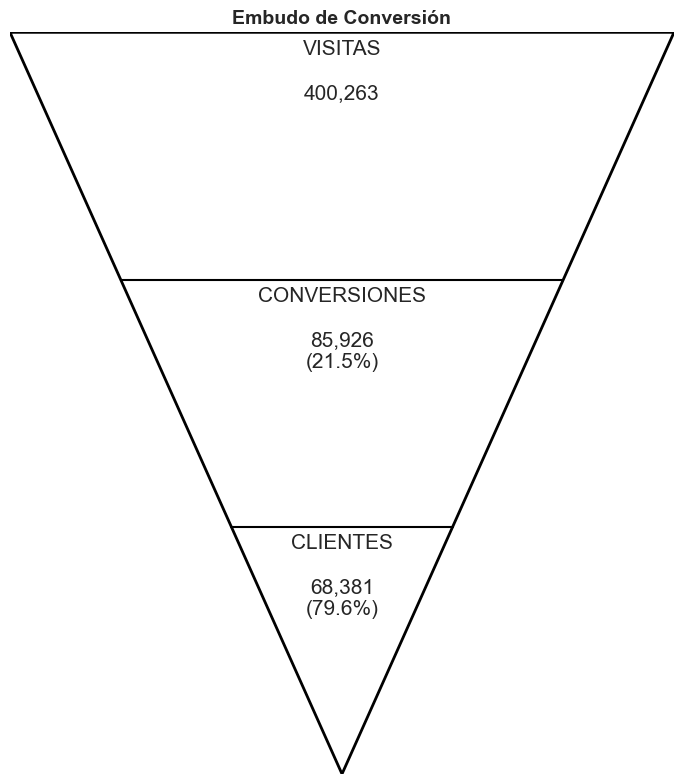

In [74]:
draw_funnel(funnel_data)

---

## 🧪 *Experimentación en los negocios pruebas A/B*


Una prueba A/B compara dos versiones de algo para identificar cuál tiene mejor rendimiento en una métrica clave.

* *Grupo de control:* recibe lo habitual.
* *Grupo experimental:* recibe la nueva funcionalidad.
* *Hipótesis nula (H₀):* no hay diferencia.
* *Hipótesis alternativa (H₁):* sí hay diferencia.
* *Error tipo I:* falso positivo (rechazas H₀ cuando es cierta).
* *Error tipo II:* falso negativo (aceptas H₀ cuando es falsa).
* *Valor p:* ¿qué tan probable es ver esta diferencia si H₀ es cierta?




**🧪Objetivo del experimento:**  
Evaluar si una nueva versión de una página web (grupo B) mejora la tasa de conversión respecto a la versión actual (grupo A).

**Hipótesis estadísticas:**

- **H₀ (hipótesis nula):** No hay diferencia en la tasa de conversión entre los grupos A y B ($p_A = p_B$).
- **H₁ (hipótesis alternativa):** La tasa de conversión del grupo B es diferente a la del grupo A ($p_A \ne p_B$).




📄 **Diccionario de datos**

| Variable     | Tipo       | Descripción                                              |
|--------------|------------|----------------------------------------------------------|
| grupo        | categórica | Grupo asignado al usuario: 'A' (control) o 'B' (test)    |
| conversion   | binaria    | Resultado: 1 si convirtió, 0 si no convirtió             

In [75]:
ab_test_landing_page_data=pd.read_csv("https://raw.githubusercontent.com/30lm32/ml-ab-testing/refs/heads/master/ab_data.csv")

In [76]:
treatment = ab_test_landing_page_data.query("group =='treatment'")['converted']
control = ab_test_landing_page_data.query("group =='control'")['converted']
alpha = 0.05

In [77]:
(
    ab_test_landing_page_data
        .groupby('group',as_index=False)
        .agg(
            rate =('converted','mean')
        )
        .round(3)
)

,group,rate
0,control,0.120
1,treatment,0.119


In [78]:
stat,p_value = ttest_ind(treatment,control,alternative='greater')

print(f"Tenemos un {p_value=:.3f} entonces con {alpha=} ")
if p_value > alpha:
    print(f"No hay evidencia de que las tasas de conversión sean diferentes")
else:
    print(f"Hay evidencia de que las tasas de conversión sean diferentes")

Tenemos un p_value=0.892 entonces con alpha=0.05 
No hay evidencia de que las tasas de conversión sean diferentes


---

## 🔁 *Intervalos de confianza via Bootstrapping*

**📊 Conceptos clave:**
* *Bootstrapping:* técnica de remuestreo con reemplazo para estimar incertidumbre (intervalos de confianza, valor p).
* *No asume distribución normal* → útil en datos reales.
* *Permite simular múltiples realidades* con solo una muestra.

In [141]:
# Revenue por campaña y clientes
(revenue_campaign
    .assign(
        LTV = lambda df: df.revenue/df.clientes
    )
    .style.format({'revenue':'${:,}','LTV':'${:,.0f}'})
 
)

,campaign,revenue,clientes,LTV
0,1,"$2,842,345",1674,"$1,698"
1,2,"$8,186,761",4476,"$1,829"
2,3,"$39,700,716",18400,"$2,158"
3,4,"$55,476,726",23722,"$2,339"
4,5,"$3,010,738",1694,"$1,777"
5,6,"$39,938,766",18415,"$2,169"


**I.C. 95% para LTV para Campaña 2**

>Un intervalo de confianza es un rango de valores donde probablemente se encuentra un parámetro poblacional, con cierta certeza estadística.

In [143]:
n_bootstrap_samples = 10000
alfa = 0.05

In [151]:
bootstrap_values= []
data_selected =(orders
        .merge(visits[['uuid_interaction','campaign']].drop_duplicates(),on='uuid_interaction')
        .query("campaign == 2")[['amount']])


for _ in range(n_bootstrap_samples):
        
    current_sample=(data_selected
        .sample(200,replace=True)
        .mean()
        .tolist()[0])
    bootstrap_values.append(current_sample)

bootstrap_values= pd.Series(bootstrap_values)
    

In [150]:
print( f"el intervalo bootstrap al {100*(1-alfa):.0f}% de confianza  para  LTV de los clientes es entre {bootstrap_values.quantile(alfa/2):.2f} y {bootstrap_values.quantile(1-alfa/2):.2f}")

el intervalo bootstrap al 95% de confianza  para  LTV de los clientes es entre 1475.60 y 2039.11


**I.C. 95% para proporción de clientes esperados por Campaña 2**


In [153]:
n_bootstrap_samples = 10000
alfa = 0.05

In [156]:
bootstrap_values=[]
data_selected=(
    visits
        .merge(orders, how='left',on='uuid_interaction')[['campaign','uuid_user','uuid_interaction','amount']]
        .drop_duplicates()


)
n_sample = 500

for _ in range(n_bootstrap_samples):
        
    current_sample=(data_selected
        .sample(n_sample,replace=True)
        .query("campaign == 2 and amount.notnull()")[['uuid_user']]
        .nunique()
        .tolist()[0])
    bootstrap_values.append(current_sample/n_sample)

bootstrap_values= pd.Series(bootstrap_values)


In [157]:
print( f"el intervalo bootstrap al {100*(1-alfa):.0f}% de confianza  para  LTV de los clientes es entre {bootstrap_values.quantile(alfa/2):.2f} y {bootstrap_values.quantile(1-alfa/2):.2f}")

el intervalo bootstrap al 95% de confianza  para  LTV de los clientes es entre 0.00 y 0.02


---